## Mountain Car


In [2]:
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

## Agente Heurístico


In [3]:
def heuristic_policy_v0(obs):
    position, velocity = obs
    if velocity < 0:
        return 0  # Move left
    else:
        return 2  # Move right


def heuristic_policy_v1(obs):
    position, velocity = obs
    if velocity > 0 or position > -0.5:
        return 2
    else:
        return 0


def heuristic_policy_v2(obs):
    position, velocity = obs
    if abs(velocity) < 0.01:
        return 1
    elif velocity > 0:
        return 2
    else:
        return 0


def heuristic_policy_v3(obs):
    THRESHOLD = 0.02
    position, velocity = obs
    if velocity > THRESHOLD:
        return 2
    else:
        return 0


def heuristic_policy_v4(obs):
    return 2

In [37]:
env = gym.make("MountainCar-v0")

N_EPISODES = 100

heuristics = [
    heuristic_policy_v0,
    heuristic_policy_v1,
    heuristic_policy_v2,
    heuristic_policy_v3,
    heuristic_policy_v4,
]

In [38]:
mean_rewards = []
rewards_by_heuristic = {}

for heuristic_policy in heuristics:
    print(f"Evaluando política: {heuristic_policy.__name__}")
    rewards = []

    for episode in range(N_EPISODES):
        obs, info = env.reset(seed=episode)
        total_reward = 0
        done = False

        while not done:
            action = heuristic_policy(obs)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            done = truncated or terminated

        rewards.append(total_reward)
        # print(f"Ep {episode+1:2d}: reward = {total_reward:.0f}")

    rewards_by_heuristic[heuristic_policy.__name__] = rewards.copy()
    mean_rewards.append(float(np.mean(rewards)))

print(f"Recompensas medias: {mean_rewards}")

Evaluando política: heuristic_policy_v0
Evaluando política: heuristic_policy_v1
Evaluando política: heuristic_policy_v2
Evaluando política: heuristic_policy_v3
Evaluando política: heuristic_policy_v4
Recompensas medias: [-120.02, -193.47, -199.72, -195.93, -200.0]


## Comparación de políticas heurísticas


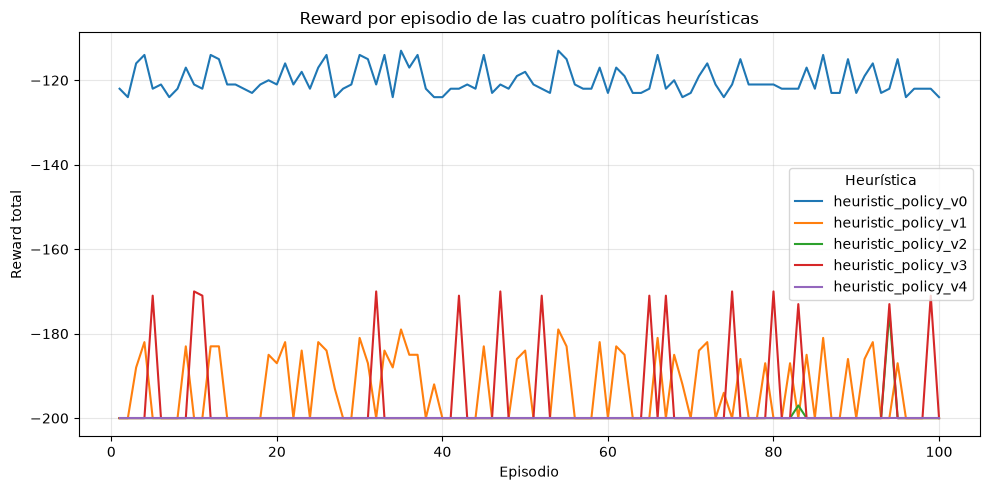

In [43]:
plt.figure(figsize=(10, 5))
episodes = range(1, N_EPISODES + 1)

for heuristic_name, episode_rewards in rewards_by_heuristic.items():
    plt.plot(episodes, episode_rewards, linewidth=1.5, label=heuristic_name)

plt.xlabel("Episodio")
plt.ylabel("Reward total")
plt.title("Reward por episodio de las cuatro políticas heurísticas")
plt.legend(title="Heurística")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Video de un episodio de Mountain Car


In [4]:
from matplotlib import animation
from IPython.display import HTML

env = gym.make("MountainCar-v0", render_mode="rgb_array")
obs, info = env.reset(seed=42)
frames = [env.render()]
observations = [obs.copy()]
step_rewards = [0.0]
actions = [None]
done = False
step = 0

# print(
#     f"Paso {step:3d} | observación={obs} | reward={step_rewards[-1]:.1f} | acción=inicio"
# )

while not done:
    action = heuristic_policy_v0(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    step += 1

    frames.append(env.render())
    observations.append(obs.copy())
    step_rewards.append(float(reward))
    actions.append(action)
    print(
        f"Paso {step:3d} | observación={obs} | reward={reward:.1f} | acción={action} | truncated={truncated} | terminated={terminated}"
    )

print(f"Recompensa total: {sum(step_rewards):.0f}")

env.close()

# Tomamos un frame de cada dos para obtener un video fluido y ligero.
frame_indexes = list(range(0, len(frames), 2))
if frame_indexes[-1] != len(frames) - 1:
    frame_indexes.append(len(frames) - 1)

fig, axis = plt.subplots(figsize=(8, 5))
image = axis.imshow(frames[0])
title = axis.set_title("Mountain Car")
status = axis.text(
    0.5,
    -0.05,
    "",
    transform=axis.transAxes,
    ha="center",
    va="top",
    family="monospace",
    fontsize=10,
)
axis.axis("off")


def update(animation_index):
    frame_index = frame_indexes[animation_index]
    position, velocity = observations[frame_index]
    action = actions[frame_index]
    action_text = "inicio" if action is None else str(action)

    image.set_data(frames[frame_index])
    title.set_text(f"Mountain Car - Paso {frame_index}")
    status.set_text(
        f"observación=[posición={position:.4f}, velocidad={velocity:.4f}]  "
        f"reward={step_rewards[frame_index]:.1f}  acción={action_text}"
    )
    return image, title, status


video = animation.FuncAnimation(
    fig, update, frames=len(frame_indexes), interval=50, blit=True, repeat=False
)
plt.close(fig)
HTML(video.to_jshtml())

Paso   1 | observación=[-4.4479132e-01  4.1747934e-04] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   2 | observación=[-0.4439594   0.00083191] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   3 | observación=[-0.4427191   0.00124029] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   4 | observación=[-0.4410795   0.00163962] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   5 | observación=[-0.43905246  0.00202703] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   6 | observación=[-0.43665275  0.00239971] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   7 | observación=[-0.43389776  0.00275498] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   8 | observación=[-0.43080744  0.00309032] | reward=-1.0 | acción=2 | truncated=False | terminated=False
Paso   9 | observación=[-0.4274041   0.00340333] | reward=-1.0 | acción=2 | truncated=False | terminated=F